# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites/plots", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'

# file_path = '../input/IGNORE_Brewster-ortho.tif'
file_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'


Image CRS - EPSG:32613


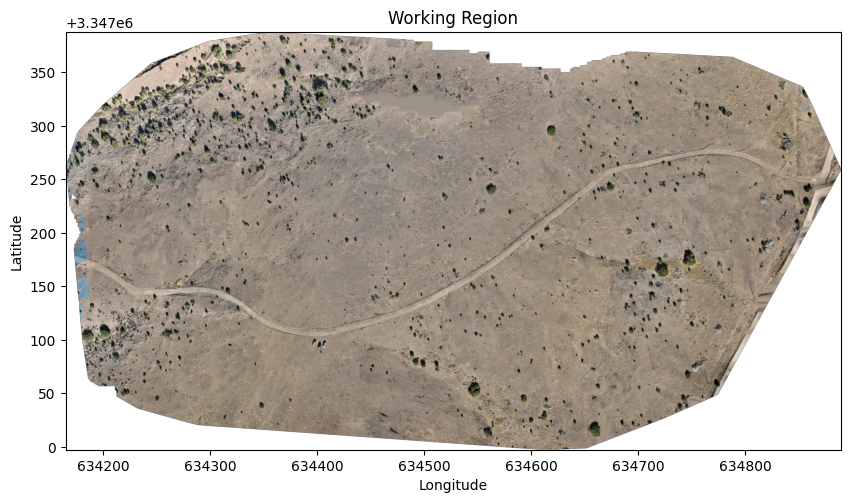

Image dimensions: (3535, 6559, 4)


In [2]:
from plant_search.load_image import load_image, plot_image, plot_geotiff

ds = 2 # downscale ratio

image, transform, bounds, image_crs = load_image(file_path)

# We have a georeferenced image
if image is not None and transform and bounds:
    original_image_shape = image.shape
    image = image[::ds, ::ds]
    # Calculate extent in geographic coordinates
    image_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    plot_geotiff(image, transform, bounds, "Working Region")

# We have image, but not georeferenced
elif image is not None and bounds:
    original_image_shape = image.shape
    height, width = image.shape[:2]
    image_extent = (0, width, 0, height)
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Image dimensions: {image.shape}")

## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [3]:
region_crs = 32613 # Use this everywhere for consistency

simplification_tolerance = 5

# Convert target area to square meters
target_area_acres = 0.5

max_iterations = 15

Reached maximum iterations without full convergence.


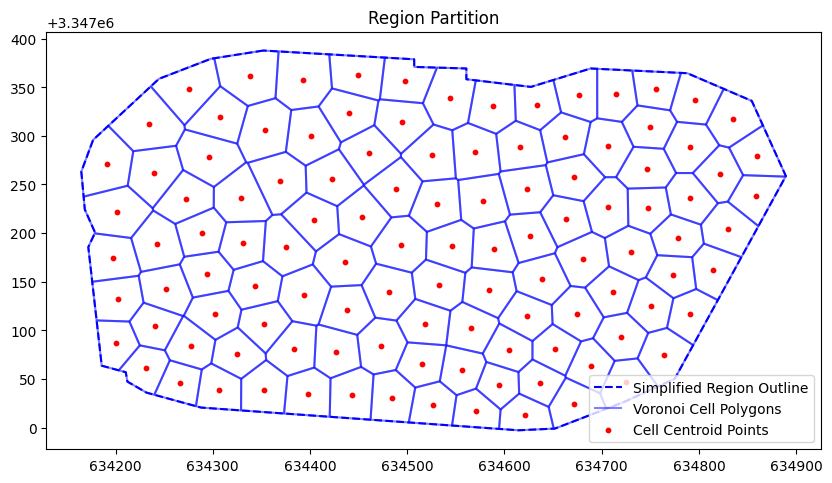

In [4]:
from plant_search.region_partition import (
    extract_region_contour,
    simplify_polygon,
    generate_voronoi_partition,
    centroidal_voronoi_tessellation,
)
import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=region_crs)  # Example: UTM Zone 14N
simplified_polygon = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)

target_area_sqm = target_area_acres * 4046.86
num_points = int(simplified_polygon.area / target_area_sqm)

# voronoi_gdf, points_gdf = generate_voronoi_partition(simplified_polygon, num_points)
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_points, max_iterations)


fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cell Polygons")
cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroid Points")

plt.legend()
plt.title("Region Partition")
plt.show()

## Macro Planning

Since we have divided our working region into smaller, more manageable portions, we can now plan our approach. We will use our cells to help measure area completion and divide work areas more efficiently. 

This section is concerned with:
- clustering of cells into trips
- prioritization of cells
- global trip efficiency
    - A.K.A. Multi-Trip Routing Problem (MTRP)
- Completion efficiency

Our planning inputs:
- cells and centroids
- base station location
    - where drones launch and land
- drone battery range
- target density per cell

In [5]:
from shapely.geometry import Point
import geopandas as gpd

# Cells
# points_gdf

# Base station location
base_station_coords = (634500,3347200)
base_station_gdf = gpd.GeoDataFrame(
    [{'geometry': Point(base_station_coords)}],
    crs=image_crs
)

# Drone battery range
trip_range = 500 # meters

# Cell densities


In [6]:
from plant_search.image_preprocess import (
    generate_target_mask,
    correct_binary_mask,
    identify_targets,
)
import rasterio

# binary_mask = generate_target_mask(image) # Generate

# Load mask the easy way
binary_mask_path = "../outputs/region_binary_mask.tif"
with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    bin_transform = src.transform  # Get the affine transform
    bin_crs = src.crs  # Get the CRS

full_binary_mask = correct_binary_mask(binary_mask, original_image_shape)
targets_gdf = identify_targets(full_binary_mask, transform)


del full_binary_mask # Save us some memory
print(f"Number of targets (detected plants): {len(targets_gdf)}")

Number of targets (detected plants): 606


In [7]:
# # Instead of re-computing, save to image
# binary_mask_scaled = (binary_mask * 255).astype("uint8")

# with rasterio.open(file_path) as src:
#     image_region_crs = src.crs

# # Save the georeferenced binary mask with the correct scaling
# with rasterio.open(
#     "../outputs/region_binary_mask.tif",
#     "w",
#     driver="GTiff",
#     height=binary_mask.shape[0],
#     width=binary_mask.shape[1],
#     count=1,
#     dtype="uint8",
#     crs=image_region_crs,
#     transform=transform,
# ) as dst:
#     dst.write(binary_mask_scaled, 1)

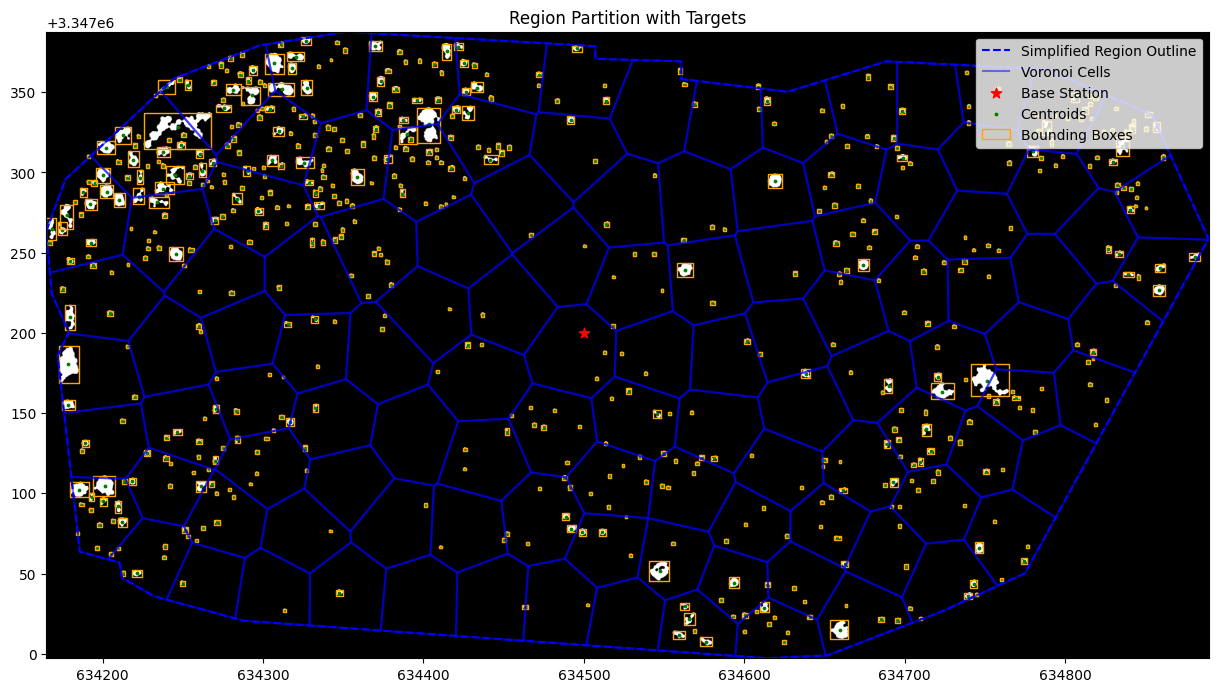

In [8]:
import matplotlib.patches as mpatches

# Display identified targets
fig, ax = plt.subplots(figsize=(15, 15))
# ax.imshow(image, extent=image_extent, alpha=0.8) # Display original image
ax.imshow(binary_mask, extent=image_extent, cmap='gray') # Show targets binary mask

# Region outline, cells, centroids
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cells") # Region cells
# cell_gdf.set_geometry('cell_centroids').plot(ax=ax, color="red", markersize=10, label="Cell Centroids")
base_station_gdf.plot(ax=ax, color='red', markersize=60, marker='*', label='Base Station')

targets_gdf.plot(ax=ax, color='green', markersize=3, label='Centroids') # Plot targets centroids
targets_gdf.set_geometry('bounding_box').plot(ax=ax, edgecolor='orange', facecolor='none', linewidth=1.0) # Plot targets bounding boxes

# Fix legend for bounding boxes
handles, labels = ax.get_legend_handles_labels()
bounding_box_patch = mpatches.Patch(edgecolor='orange', facecolor='none', label='Bounding Boxes') # Add a custom handle for the bounding boxes
handles.append(bounding_box_patch)
labels.append('Bounding Boxes')

ax.legend(handles, labels, loc='upper right')
# plt.legend()
plt.title("Region Partition with Targets")
plt.show()

### Calculate Cell Densities

First-pass system to determine:
- Number of targets in each cell
- Distance to traverse all targets in each cell

In [17]:
from plant_search.macro_planning import (
    calculate_cell_workloads,
    plot_cells_with_targets,
    plot_cells_ids,
)


calculate_cell_workloads(cell_gdf, targets_gdf) # In-place updates

# Ensure base station is a valid Point geometry

# Compute distance from each cell centroid to the base station
base_station_point = base_station_gdf.geometry.iloc[0]
cell_gdf['home_distance'] = cell_gdf['cell_centroid'].distance(base_station_point)
cell_gdf['total_workload'] = cell_gdf['workload'] + (2 * cell_gdf['home_distance'])

# print(type(cell_gdf['cell_centroid']))  # Should be GeoSeries
# print(type(base_station_point))        # Should be shapely.geometry.Point


# Visualize cell workloads
# plot_cells_with_targets(cell_gdf)
# plot_cells_ids(cell_gdf)



# targets_gdf
# joined
# cell_gdf

In [20]:
def cluster_cells_for_trips(cell_gdf, max_workload):
    # Sort cells by total workload (descending)
    sorted_cells = cell_gdf.sort_values('total_workload', ascending=False)
    
    trips = []
    current_trip = []
    current_trip_workload = 0

    for _, cell in sorted_cells.iterrows():
        cell_workload = cell['total_workload']
        if current_trip_workload + cell_workload > max_workload:
            # Finalize the current trip and start a new one
            trips.append(current_trip)
            current_trip = []
            current_trip_workload = 0
        current_trip.append(cell.name)  # Use the cell index or ID
        current_trip_workload += cell_workload

    if current_trip:  # Add the last trip
        trips.append(current_trip)

    return trips

# Example usage
max_workload = 4500  # Replace with actual drone battery capacity
trip_clusters = cluster_cells_for_trips(cell_gdf, max_workload)
print("Trip Clusters:", trip_clusters)


Trip Clusters: [[110, 111, 112, 0, 11], [4, 104, 109, 2, 12, 3], [106, 5, 108, 103, 1, 6], [61, 107, 7, 102, 17, 18, 105], [92, 25, 101, 9, 98, 36, 10], [13, 96, 100, 97, 95, 26, 84, 94], [60, 93, 99, 19, 8, 90, 73, 91], [14, 22, 16, 87, 89, 80, 86, 67, 83], [32, 39, 31, 23, 85, 30, 15, 78, 70, 20], [21, 88, 24, 28, 50, 82, 75, 41, 29, 68, 42, 43], [27, 55, 76, 35, 47, 38, 53, 63, 62, 72, 79, 66, 77, 34], [58, 52, 81, 33, 64, 69, 48, 59, 56, 49, 71, 37, 45, 40, 74, 44, 57, 65, 46, 51, 54]]


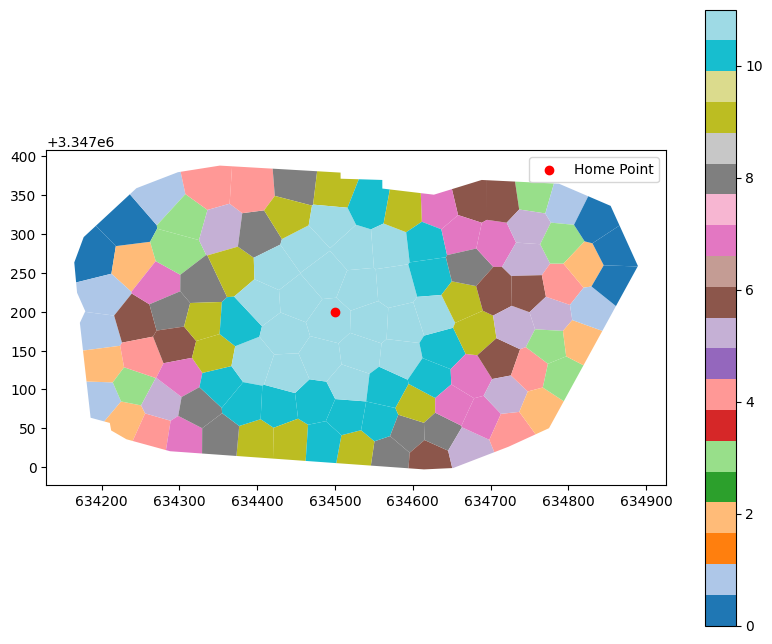

In [22]:
import matplotlib.pyplot as plt

# Assign trip IDs back to the GeoDataFrame
for trip_id, trip_cells in enumerate(trip_clusters):
    cell_gdf.loc[trip_cells, 'trip_id'] = trip_id

# Plot trips
fig, ax = plt.subplots(figsize=(10, 8))
cell_gdf.plot(ax=ax, column='trip_id', legend=True, cmap='tab20')
plt.scatter(*base_station_point.xy, color='red', label='Home Point', zorder=5)
plt.legend()
plt.show()


### Data Relations

Finally, after much computation, we can now begin to treat our GDFs as database tables and relate them. 

First, we attempt to associate each target with a cell.

In [10]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp


# Step 2: Cluster Cells for Trips
def cluster_cells_by_workload(cell_workloads, max_workload):
    sorted_cells = sorted(cell_workloads.items(), key=lambda x: x[1], reverse=True)
    trips = []
    current_trip = []
    current_workload = 0

    for cell, workload in sorted_cells:
        if current_workload + workload > max_workload:
            trips.append(current_trip)
            current_trip = []
            current_workload = 0
        current_trip.append(cell)
        current_workload += workload
    if current_trip:
        trips.append(current_trip)
    return trips


# Step 3: Optimize Target Visits Within Each Trip
def optimize_trip_targets(trip_cells, targets, base_point):
    # Combine all targets from the trip's cells
    trip_targets = np.vstack([targets[cell] for cell in trip_cells])
    all_points = np.vstack([base_point, trip_targets])

    # Solve TSP for the trip
    num_points = len(all_points)
    dist_matrix = cdist(all_points, all_points)

    manager = pywrapcp.RoutingIndexManager(num_points, 1, 0)  # Start at base
    routing = pywrapcp.RoutingModel(manager)
    transit_callback_index = routing.RegisterTransitCallback(
        lambda i, j: int(dist_matrix[manager.IndexToNode(i)][manager.IndexToNode(j)])
    )
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    solution = routing.SolveWithParameters(search_parameters)

    # Extract optimized route
    if solution:
        route = []
        index = routing.Start(0)
        while not routing.IsEnd(index):
            route.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))
        return route
    return None

In [11]:
# Input data
max_workload = 1000  # Arbitrary drone capacity (sum of distances)

cell_workloads = cell_gdf['workload']
# print("Cell Workloads:", cell_workloads)

trips = cluster_cells_by_workload(cell_workloads, max_workload)
print("Trips:", trips)

# for trip in trips:
#     optimized_route = optimize_trip_targets(trip, targets, base_point)
#     print(f"Optimized Route for Trip {trip}: {optimized_route}")

KeyError: 'workload'

## Micro Planning

Perform image analysis on each smaller section of our greater region.

In [12]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping

# Path to the original image
# raster_path = "path_to_your_image.tif"

# Example: Select a Voronoi polygon by an attribute or ID
selected_partition = voronoi_gdf[voronoi_gdf['id'] == 0]


# Convert the selected polygon to GeoJSON-like format
# geometry = [mapping(selected_partition.geometry.iloc[0])]

# # Open the raster and clip it
# with rasterio.open(file_path) as src:
#     out_image, out_transform = mask(src, geometry, crop=True)
#     out_meta = src.meta.copy()

# # Update metadata for the clipped section
# out_meta.update({
#     "driver": "GTiff",
#     "height": out_image.shape[1],
#     "width": out_image.shape[2],
#     "transform": out_transform
# })
